In [1]:
PROJ_NAME = "dilithium_poly_decompose_ttest"
LABEL = ""

In [2]:
import sys
sys.path.insert(0, "../")
from host.ttest_trace_collector import TTestTraceCollector

In [3]:
trace_collector = TTestTraceCollector(proj_name=PROJ_NAME, label=LABEL, input_len=32,
                                      output_len=0)

In [ ]:
trace_collector.init_target(force=True)

In [ ]:
trace_collector.default_setup(40E6, 12, 34000)

In [ ]:
trace_collector.build_fw()
trace_collector.program_fw()

-DDILITHIUM_MODE=3 -DSS_VER=1 -O3 -I../../../../fw/dilithium_hw -I../victims_commons -I../../driver -I../../simpleserial -I../../../../sdk/lib -march=rv32im -mabi=ilp32 -mstrict-align -T ../../../../sdk/toolchain/linksc.ld -flto -ffunction-sections -fdata-sections -nostartfiles -o dilithium_poly_decompose_ttest.elf
/opt/riscv/bin/riscv64-unknown-elf-gcc dilithium_poly_decompose_ttest.c ../../../../fw/dilithium_hw/packing.c ../../../../fw/dilithium_hw/poly.c ../../../../fw/dilithium_hw/polyvec.c ../../../../fw/dilithium_hw/randombytes.c ../../../../fw/dilithium_hw/sign.c ../../../../fw/dilithium_hw/symmetric.c ../../../../fw/dilithium_hw/reduce.c ../../../../fw/dilithium_hw/masked.c ../../../../fw/dilithium_hw/masked_sign.c ../../../../fw/dilithium_hw/masked_poly.c ../../../../fw/dilithium_hw/masked_polyvec.c ../../../../fw/dilithium_hw/masked_gadgets.c ../../../../fw/dilithium_hw/masked_packing.c ../../../../fw/dilithium_hw/masked_symmetric.c ../victims_commons/victims_commons_util.c .

../fw/victims/dilithium_poly_decompose_ttest/dilithium_poly_decompose_ttest.inst.bin: 100%|██████████| 4.33k/4.33k [00:03<00:00, 1.18kB/s]
../fw/victims/dilithium_poly_decompose_ttest/dilithium_poly_decompose_ttest.data.bin:   0%|          | 0.00/1.07k [00:00<?, ?B/s]

File transmission complete for ../fw/victims/dilithium_poly_decompose_ttest/dilithium_poly_decompose_ttest.inst.bin.
Sending file: ../fw/victims/dilithium_poly_decompose_ttest/dilithium_poly_decompose_ttest.data.bin


../fw/victims/dilithium_poly_decompose_ttest/dilithium_poly_decompose_ttest.data.bin: 100%|██████████| 1.07k/1.07k [00:01<00:00, 816B/s]


File transmission complete for ../fw/victims/dilithium_poly_decompose_ttest/dilithium_poly_decompose_ttest.data.bin.
Program load complete.
Serial port closed.


# PRNG=OFF

In [8]:
trace_collector.collect_traces(N=1000, prng_off=True, overwrite=True, check_output=False, dummy_inbetween_1=True)

Capturing traces:   0%|          | 0/1000 [00:00<?, ?it/s]

In [9]:
ttest_analysis_off = trace_collector.get_analysis_obj(N=1000, prng_off=True)

Trace Header Set:
Name.............: ETS Format THS
Reader...........: ETS format reader of file traces/dilithium_poly_decompose_ttest_N1000_prngoff1_r0_o0_.ets with 1000 traces.
s................: float64

Trace Header Set:
Name.............: ETS Format THS
Reader...........: ETS format reader of file traces/dilithium_poly_decompose_ttest_N1000_prngoff1_r1_o0_.ets with 1000 traces.
s................: float64



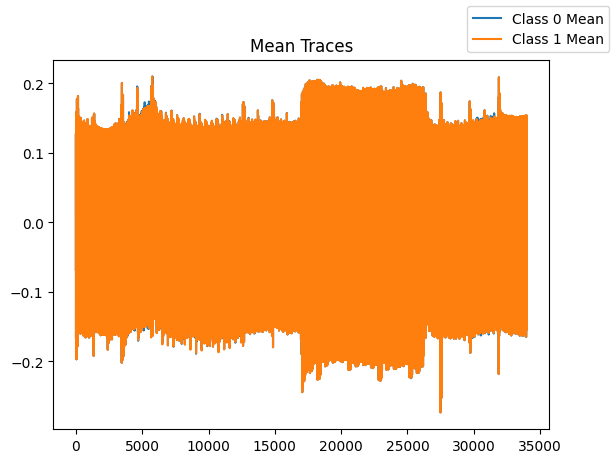

In [10]:
ttest_analysis_off.plot_means()

In [11]:
ttest_analysis_off.run_ttest()

Running T-Test:   0%|          | 0/1 [00:00<?, ?it/s]

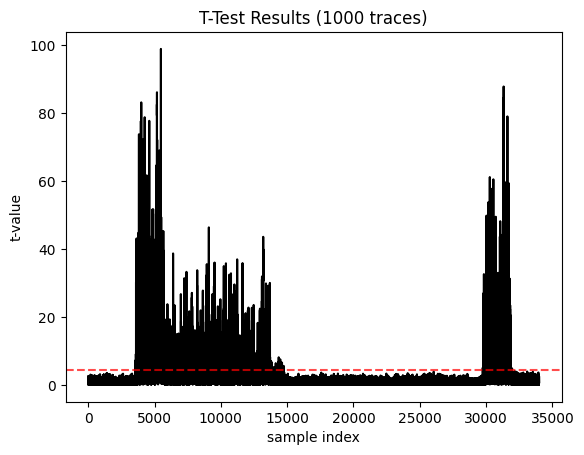

In [12]:
ttest_analysis_off.plot_ttest()

# PRNG=ON

In [15]:
trace_collector.collect_traces(N=100000, prng_off=False, overwrite=True, check_output=False, dummy_inbetween_0=True, dummy_inbetween_1=True)

Capturing traces:   0%|          | 0/100000 [00:00<?, ?it/s]

(ChipWhisperer Target WARNING|File SimpleSerial.py:414) Unexpected start to command: z
(ChipWhisperer Target WARNING|File SimpleSerial.py:414) Unexpected start to command: 0


KeyboardInterrupt: 

In [11]:
ttest_analysis_on = trace_collector.get_analysis_obj(N=10, prng_off=False)

Trace Header Set:
Name.............: ETS Format THS
Reader...........: ETS format reader of file traces/kyber_poly_tomsg_ttest_N10_prngoff0_r0_newx2x with 10 traces.
s................: float64

Trace Header Set:
Name.............: ETS Format THS
Reader...........: ETS format reader of file traces/kyber_poly_tomsg_ttest_N10_prngoff0_r1_newx2x with 10 traces.
s................: float64



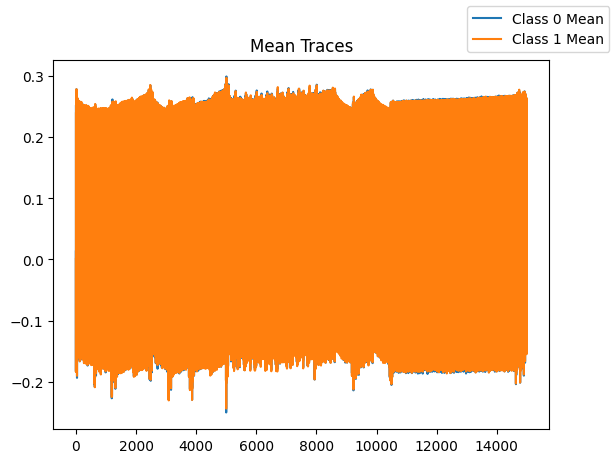

In [12]:
ttest_analysis_on.plot_means()

In [ ]:
ttest_analysis_on.run_ttest()

/home/toluntosun/miniconda3/envs/sca/lib/python3.12/site-packages/traitlets/traitlets.py:1385: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
NavigationToolbar2WebAgg.__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  warn(


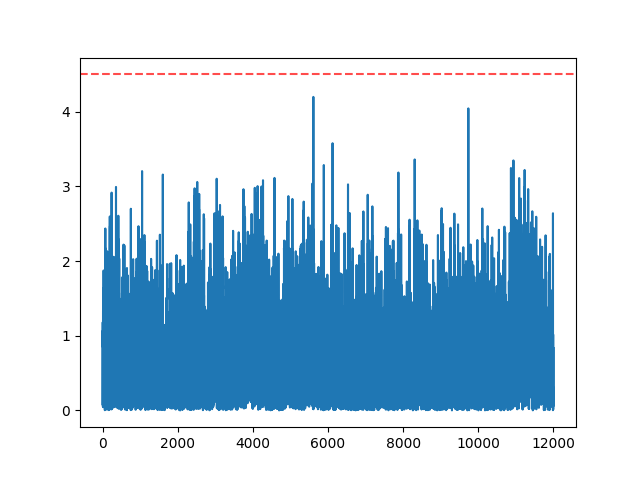

In [ ]:
ttest_analysis_on.plot_ttest(ylimit=10)

## ARCHIVE

In [ ]:
# def test_comm():
#     seed = os.urandom(32)
#     target.simpleserial_write('p', seed)
#     ret = target.simpleserial_read('r', 16)
#     msg = seed_to_poly_to_msg(seed, debug=True)
#     print(msg.hex())
#     m_ = bytearray(ret)
#     print(m_.hex())
#     for i in range(len(m_) // 2):
#         m_[i] ^= m_[i + (len(m_) // 2)]
#     assert m_[:(len(m_) // 2)] == msg[:(len(m_) // 2)], "Output mismatch!"


In [ ]:
# import os
# from Crypto.Hash import SHAKE256
# from kyber_py.kyber.default_parameters import Kyber768 as kyber_py


# def seed_to_poly_to_msg(seed=os.urandom(32), debug=False):
#     poly_size = 256*12//8
#     poly_bytes = SHAKE256.new(seed).read(poly_size)
#     if debug:
#         print(poly_bytes.hex())
#     poly = kyber_py.R.decode(poly_bytes, 12)
#     if debug:
#         print(poly)
#     return poly.compress(1).encode(1)


# class PolyToMsgTTestTraceCollector(TTestTraceCollector):
#     def check_output(self, out, seed):
#         msg = seed_to_poly_to_msg(seed)
#         m_ = bytearray(out)
#         for i in range(len(m_) // 2):
#             m_[i] ^= m_[i + (len(m_) // 2)]
#         return m_[:(len(m_) // 2)] == msg[:(len(m_) // 2)]

In [ ]:
# trace_collector.target.simpleserial_write('l', [])

In [ ]:
# data = os.urandom(16)

In [ ]:
# import time
# for i in range(1):
#     mask = os.urandom(16)
#     masked_data = bytes([(data[i] ^ mask[i]) for i in range(len(data))])
#     trace_collector.target.simpleserial_write('p', masked_data + mask)
#     time.sleep(3)